<a href="https://colab.research.google.com/github/Tanishkaaa016/EEG-Based-Epileptic-Seizure-Detection-Using-Sample-Entropy-and-Random-Forest-Classification/blob/main/notebooks/eeg_MI_UROP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!wget -r -N -c -np https://physionet.org/files/chbmit/1.0.0/chb01/

zsh:1: command not found: wget


In [7]:
!find physionet.org/files/chbmit/1.0.0/chb01 -name "*.edf" | tail

find: physionet.org/files/chbmit/1.0.0/chb01: No such file or directory


In [8]:
!find physionet.org/files/chbmit/1.0.0/chb01 -name "*.edf.seizures"

find: physionet.org/files/chbmit/1.0.0/chb01: No such file or directory


In [13]:
import mne

raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=False,
    verbose=False
)

print("Sampling Frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print(raw.ch_names)

Sampling Frequency: 256.0
Channels: 23
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


/var/folders/ry/zzrs0_3x24vcvl3sgtdzfh3c0000gn/T/ipykernel_58073/501970560.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [10]:
find ~ -name "chb01_03.edf" 2>/dev/null

SyntaxError: invalid syntax (4091559533.py, line 1)

In [ ]:
!pip install mne pywavelets antropy xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.0 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
!find physionet.org/files/chbmit/1.0.0/chb01 -name "*.edf" | wc -l

42


In [ ]:
import mne

raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=False,
    verbose=False
)

print("Sampling Frequency:", raw.info["sfreq"])
print("Number of Channels:", len(raw.ch_names))
print(raw.ch_names)

Sampling Frequency: 256.0
Number of Channels: 23
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


/tmp/ipykernel_40506/3315765363.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [ ]:
!find physionet.org/files/chbmit/1.0.0/chb01 -name "*.edf" | wc -l

42


In [ ]:
import mne
print(mne.__version__)

1.12.1


In [ ]:
raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=False,
    verbose=False
)

print("Sampling Frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))

Sampling Frequency: 256.0
Channels: 23


/tmp/ipykernel_40506/4288975396.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [14]:
import numpy as np
import mne
from scipy.signal import butter, filtfilt

FS = 256

def bandpass_filter(data, lowcut=0.5, highcut=40, fs=256, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        data,
        axis=-1
    )

# Load seizure file
raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=True,
    verbose=False
)

data = raw.get_data()

print("Original shape:", data.shape)

# Filter
data = bandpass_filter(data)

# Normalize
data = (
    data -
    np.mean(data, axis=1, keepdims=True)
) / (
    np.std(data, axis=1, keepdims=True)
    + 1e-8
)

print("Processed shape:", data.shape)

/var/folders/ry/zzrs0_3x24vcvl3sgtdzfh3c0000gn/T/ipykernel_58073/4278811978.py:28: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


Original shape: (23, 921600)
Processed shape: (23, 921600)


In [15]:
WINDOW_SIZE = 256

windows = []

for start in range(
    0,
    data.shape[1] - WINDOW_SIZE,
    WINDOW_SIZE
):

    window = data[
        :,
        start:start + WINDOW_SIZE
    ]

    windows.append(window)

windows = np.array(windows)

print("Windows shape:", windows.shape)

Windows shape: (3599, 23, 256)


In [16]:
print(windows[0].shape)

(23, 256)


In [ ]:
print("Processed shape:", data.shape)
print("Windows shape:", windows.shape)

Processed shape: (23, 921600)
Windows shape: (3599, 23, 256)


In [ ]:
import numpy as np
from scipy.stats import skew, kurtosis

In [17]:
def extract_time_features(window):

    features = []

    for ch in window:

        mean_val = np.mean(ch)

        var_val = np.var(ch)

        rms_val = np.sqrt(
            np.mean(ch**2)
        )

        line_length = np.sum(
            np.abs(
                np.diff(ch)
            )
        )

        zcr = np.sum(
            np.diff(
                np.sign(ch)
            ) != 0
        )

        features.extend([
            mean_val,
            var_val,
            rms_val,
            line_length,
            zcr
        ])

    return np.array(features)

In [ ]:
feat = extract_time_features(
    windows[0]
)

print(feat.shape)

(115,)


In [27]:
time_features = []

for win in windows:

    f = extract_time_features(win)

    time_features.append(f)

time_features = np.array(
    time_features
)

print(time_features.shape)

(3599, 115)


In [ ]:
print(feat.shape)
print(time_features.shape)

(115,)
(3599, 115)


In [30]:
from scipy.signal import welch

def extract_frequency_features(window, fs=256):

    features = []

    for ch in window:

        freqs, psd = welch(
            ch,
            fs=fs,
            nperseg=128
        )

        delta = np.sum(
            psd[(freqs >= 0.5) & (freqs < 4)]
        )

        theta = np.sum(
            psd[(freqs >= 4) & (freqs < 8)]
        )

        alpha = np.sum(
            psd[(freqs >= 8) & (freqs < 13)]
        )

        beta = np.sum(
            psd[(freqs >= 13) & (freqs < 30)]
        )

        gamma = np.sum(
            psd[(freqs >= 30) & (freqs < 40)]
        )

        features.extend([
            delta,
            theta,
            alpha,
            beta,
            gamma
        ])

    return np.array(features)

In [31]:
print("extract_frequency_features" in globals())

True


In [ ]:
freq_feat = extract_frequency_features(
    windows[0]
)

print(freq_feat.shape)

(115,)


In [ ]:
frequency_features = []

for win in windows:

    f = extract_frequency_features(win)

    frequency_features.append(f)

frequency_features = np.array(
    frequency_features
)

print(frequency_features.shape)

(3599, 115)


In [ ]:
import numpy as np

def sample_entropy(signal, m=2, r=None):

    if r is None:
        r = 0.2 * np.std(signal)

    N = len(signal)

    def _phi(m):

        x = np.array(
            [signal[i:i+m]
             for i in range(N-m+1)]
        )

        C = np.sum(
            np.max(
                np.abs(
                    x[:, None] - x[None, :]
                ),
                axis=2
            ) <= r,
            axis=0
        ) - 1

        return np.sum(C)

    try:

        return -np.log(
            _phi(m+1) / _phi(m)
        )

    except:

        return 0

In [18]:
from antropy import sample_entropy
from antropy import perm_entropy

def extract_entropy_features(window):

    features = []

    for ch in window:

        # Sample Entropy
        se = sample_entropy(ch)

        # Permutation Entropy
        pe = perm_entropy(
            ch,
            order=3,
            normalize=True
        )

        features.extend([
            se,
            pe
        ])

    return np.array(features)

In [26]:
test = extract_entropy_features(
    windows4[0]
)

print(test.shape)

NameError: name 'windows4' is not defined

In [20]:
print("data exists:", "data" in globals())

data exists: True


In [21]:
WINDOW_SIZE = 256

windows = []

for start in range(
    0,
    data.shape[1] - WINDOW_SIZE,
    WINDOW_SIZE
):
    windows.append(
        data[:, start:start + WINDOW_SIZE]
    )

windows = np.array(windows)

print(type(windows))
print(windows.shape)

<class 'numpy.ndarray'>
(3599, 23, 256)


In [22]:
print(windows.shape)

(3599, 23, 256)


In [ ]:
entropy_feat = extract_entropy_features(
    windows[0]
)

print(entropy_feat.shape)

(23,)


In [23]:
test = extract_entropy_features(
    windows[0]
)

print(test.shape)

(46,)


In [24]:
entropy_features = []

for i, win in enumerate(windows):

    if i % 500 == 0:
        print(i)

    entropy_features.append(
        extract_entropy_features(win)
    )

entropy_features = np.array(
    entropy_features
)

print(entropy_features.shape)

0
500
1000
1500
2000
2500
3000
3500
(3599, 46)


In [25]:
print(time_features.shape)
print(frequency_features.shape)
print(entropy_features.shape)

NameError: name 'time_features' is not defined

In [28]:
time_features = []

for i, win in enumerate(windows):

    if i % 500 == 0:
        print(i)

    time_features.append(
        extract_time_features(win)
    )

time_features = np.array(time_features)

print(time_features.shape)

0
500
1000
1500
2000
2500
3000
3500
(3599, 115)


In [32]:
frequency_features = []

for i, win in enumerate(windows):

    if i % 500 == 0:
        print(i)

    frequency_features.append(
        extract_frequency_features(win)
    )

frequency_features = np.array(
        frequency_features
)

print(frequency_features.shape)

0
500
1000
1500
2000
2500
3000
3500
(3599, 115)


In [33]:
print(frequency_features.shape)

(3599, 115)


In [34]:
print(time_features.shape)
print(frequency_features.shape)
print(entropy_features.shape)

(3599, 115)
(3599, 115)
(3599, 46)


In [35]:
X = np.hstack([
    time_features,
    frequency_features,
    entropy_features
])

print(X.shape)

(3599, 276)


In [36]:
print("y exists:", "y" in globals())

y exists: False


In [ ]:
entropy_features = []

for win in windows:

    entropy_features.append(
        extract_entropy_features(win)
    )

entropy_features = np.array(
    entropy_features
)

print(entropy_features.shape)

In [ ]:
entropy_features = []

for win in windows[:500]:
    entropy_features.append(
        extract_entropy_features(win)
    )

entropy_features = np.array(entropy_features)

print(entropy_features.shape)

NameError: name 'windows' is not defined

In [ ]:
print("data" in globals())
print("windows" in globals())
print("time_features" in globals())
print("frequency_features" in globals())

False
False
False
False


In [ ]:
WINDOW_SIZE = 256

windows = []

for start in range(
    0,
    data.shape[1] - WINDOW_SIZE,
    WINDOW_SIZE
):
    window = data[:, start:start + WINDOW_SIZE]
    windows.append(window)

windows = np.array(windows)

print(windows.shape)

NameError: name 'data' is not defined

In [ ]:
raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=True,
    verbose=False
)

data = raw.get_data()

NameError: name 'mne' is not defined

In [ ]:
import numpy as np
import mne
from scipy.signal import butter, filtfilt
from scipy.signal import welch

In [ ]:
print(mne.__version__)

1.12.1


In [ ]:
raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=True,
    verbose=False
)

data = raw.get_data()

print(data.shape)

/tmp/ipykernel_44647/704491033.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


(23, 921600)


In [ ]:
!ls physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf

physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf


In [ ]:
import numpy as np
import mne
from scipy.signal import butter, filtfilt, welch

print("Imports successful")
print("MNE version:", mne.__version__)

Imports successful
MNE version: 1.12.1


In [ ]:
!find physionet.org/files/chbmit/1.0.0/chb01 -name "chb01_03.edf"

physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf


In [12]:
raw = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    preload=True,
    verbose=False
)

data = raw.get_data()

print(data.shape)

/var/folders/ry/zzrs0_3x24vcvl3sgtdzfh3c0000gn/T/ipykernel_58073/2228856095.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


(23, 921600)


In [11]:
def bandpass_filter(data, lowcut=0.5, highcut=40, fs=256, order=4):

    nyquist = 0.5 * fs

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    return filtfilt(
        b,
        a,
        data,
        axis=-1
    )

data = bandpass_filter(data)

data = (
    data -
    np.mean(data, axis=1, keepdims=True)
) / (
    np.std(data, axis=1, keepdims=True) + 1e-8
)

print(data.shape)

NameError: name 'data' is not defined

In [ ]:
WINDOW_SIZE = 256

windows = []

for start in range(
    0,
    data.shape[1] - WINDOW_SIZE,
    WINDOW_SIZE
):
    windows.append(
        data[:, start:start+WINDOW_SIZE]
    )

windows = np.array(windows)

print(windows.shape)

(3599, 23, 256)


In [ ]:
np.save("windows.npy", windows)

In [ ]:
windows.shape

(3599, 23, 256)

In [ ]:
baseline_features = np.hstack([
    time_features,
    frequency_features
])

print(baseline_features.shape)

NameError: name 'time_features' is not defined

In [ ]:
print("windows:", "windows" in globals())
print("time_features:", "time_features" in globals())
print("frequency_features:", "frequency_features" in globals())

windows: True
time_features: False
frequency_features: False


In [ ]:
time_features = []

for win in windows:
    f = extract_time_features(win)
    time_features.append(f)

time_features = np.array(time_features)

print(time_features.shape)

NameError: name 'extract_time_features' is not defined

In [ ]:
print("windows" in globals())
print("extract_time_features" in globals())
print("extract_frequency_features" in globals())

True
False
False


In [ ]:
import numpy as np

def extract_time_features(window):

    features = []

    for ch in window:

        mean_val = np.mean(ch)

        var_val = np.var(ch)

        rms_val = np.sqrt(
            np.mean(ch**2)
        )

        line_length = np.sum(
            np.abs(
                np.diff(ch)
            )
        )

        zcr = np.sum(
            np.diff(
                np.sign(ch)
            ) != 0
        )

        features.extend([
            mean_val,
            var_val,
            rms_val,
            line_length,
            zcr
        ])

    return np.array(features)

In [ ]:
print(extract_time_features(windows[0]).shape)

(115,)


In [ ]:
print("windows" in globals())
print("extract_time_features" in globals())
print("extract_frequency_features" in globals())

True
True
False


In [ ]:
# ==================================================
# SECTION 1 - IMPORTS
# ==================================================

import numpy as np
import mne
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis

In [ ]:
# ==================================================
# SECTION 2 - FUNCTIONS
# ==================================================

def bandpass_filter(...):
    ...

def extract_time_features(...):
    ...

def extract_frequency_features(...):
    ...

SyntaxError: invalid syntax (842187099.py, line 5)

In [ ]:
print("windows" in globals())
print("time_features" in globals())
print("frequency_features" in globals())
print("raw" in globals())
print("data" in globals())

True
True
False
True
True


In [ ]:
from scipy.signal import welch

def extract_frequency_features(window, fs=256):

    features = []

    for ch in window:

        freqs, psd = welch(
            ch,
            fs=fs,
            nperseg=128
        )

        delta = np.sum(psd[(freqs >= 0.5) & (freqs < 4)])
        theta = np.sum(psd[(freqs >= 4) & (freqs < 8)])
        alpha = np.sum(psd[(freqs >= 8) & (freqs < 13)])
        beta  = np.sum(psd[(freqs >= 13) & (freqs < 30)])
        gamma = np.sum(psd[(freqs >= 30) & (freqs < 40)])

        features.extend([
            delta,
            theta,
            alpha,
            beta,
            gamma
        ])

    return np.array(features)

In [ ]:
freq_feat = extract_frequency_features(
    windows[0]
)

print(freq_feat.shape)

(115,)


In [ ]:
frequency_features = []

for win in windows:

    frequency_features.append(
        extract_frequency_features(win)
    )

frequency_features = np.array(
    frequency_features
)

print(frequency_features.shape)

(3599, 115)


In [ ]:
np.save(
    "frequency_features.npy",
    frequency_features
)

In [ ]:
baseline_features = np.hstack([
    time_features,
    frequency_features
])

print(baseline_features.shape)

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [ ]:
print(frequency_features.shape)

(3599, 115)


In [ ]:
baseline_features = np.hstack([
    time_features,
    frequency_features
])

print(baseline_features.shape)

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)

In [ ]:
print(type(time_features))
print(type(frequency_features))

print(np.shape(time_features))
print(np.shape(frequency_features))

<class 'list'>
<class 'numpy.ndarray'>
(0,)
(3599, 115)


In [ ]:
print(windows.shape)

(3599, 23, 256)


In [ ]:
time_features = []

for win in windows:
    time_features.append(
        extract_time_features(win)
    )

time_features = np.array(
    time_features
)

print(time_features.shape)

(3599, 115)


In [ ]:
np.save(
    "time_features.npy",
    time_features
)

In [ ]:
baseline_features = np.hstack([
    time_features,
    frequency_features
])

print(baseline_features.shape)

(3599, 230)


In [ ]:
np.save("windows.npy", windows)
np.save("time_features.npy", time_features)
np.save("frequency_features.npy", frequency_features)
np.save("baseline_features.npy", baseline_features)

In [ ]:
X = baseline_features

In [ ]:
!cat physionet.org/files/chbmit/1.0.0/chb01/chb01_03.edf.seizures

 X�## time resolution: 256  �����  �  � � �   ( �  

In [ ]:
with open(
    ""/Users/tanishkabajpai/Downloads/chb01_03.edf.seizures"",
    "r"
) as f:

    print(f.read())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xfc in position 3: invalid start byte

In [ ]:
!pip install wfdb -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import wfdb

ann = wfdb.rdann(
    "/Users/tanishkabajpai/Downloads/chb01_03.edf",
    extension="seizures"
)

print(ann.sample)
print(ann.symbol)

[766976 777216]
['[', ']']


In [ ]:
n_windows = windows.shape[0]

y = np.zeros(n_windows)

seizure_start = 2996
seizure_end = 3036

for i in range(n_windows):

    window_start = i
    window_end = i + 1

    if (
        window_end > seizure_start
        and
        window_start < seizure_end
    ):
        y[i] = 1

print("Total windows:", len(y))
print("Seizure windows:", int(np.sum(y)))
print("Non-seizure windows:", int(len(y)-np.sum(y)))

Total windows: 3599
Seizure windows: 40
Non-seizure windows: 3559


In [ ]:
print(baseline_features.shape)
print(y.shape)

(3599, 230)
(3599,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score
)

X_train, X_test, y_train, y_test = train_test_split(
    baseline_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sensitivity:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9958333333333333
Sensitivity: 0.75
F1 Score: 0.8


In [ ]:
np.save("baseline_features.npy", baseline_features)
np.save("labels.npy", y)

In [ ]:
!pip install antropy -q

In [ ]:
import antropy as ant
import numpy as np

def extract_entropy_features(window):

    features = []

    for ch in window:

        se = ant.sample_entropy(ch)

        features.append(se)

    return np.array(features)

In [ ]:
entropy_test = extract_entropy_features(windows[0])

print(entropy_test.shape)

(23,)


In [ ]:
entropy_features = []

for i, win in enumerate(windows):

    entropy_features.append(
        extract_entropy_features(win)
    )

    if i % 500 == 0:
        print(i)

entropy_features = np.array(
    entropy_features
)

print(entropy_features.shape)

0
500
1000
1500
2000
2500
3000
3500
(3599, 23)


In [ ]:
np.save(
    "entropy_features.npy",
    entropy_features
)

In [ ]:
proposed_features = np.hstack([
    baseline_features,
    entropy_features
])

print(proposed_features.shape)

(3599, 253)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score
)

X_train, X_test, y_train, y_test = train_test_split(
    proposed_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_entropy = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_entropy.fit(
    X_train,
    y_train
)

y_pred_entropy = rf_entropy.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_entropy)
)

print(
    "Sensitivity:",
    recall_score(y_test, y_pred_entropy)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_entropy)
)

Accuracy: 0.9972222222222222
Sensitivity: 0.75
F1 Score: 0.8571428571428571


In [ ]:
!pip install imbalanced-learn -q

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print(np.bincount(y_train_balanced.astype(int)))

[2847 2847]


In [ ]:
rf.fit(
    X_train_balanced,
    y_train_balanced
)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.30).astype(int)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    proposed_features,   # or baseline_features
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

rf.fit(
    X_train_balanced,
    y_train_balanced
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=15,
                       n_estimators=300, random_state=42)

In [ ]:
y_prob = rf.predict_proba(X_test)[:, 1]

y_pred = (y_prob > 0.30).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sensitivity:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9930555555555556
Sensitivity: 1.0
F1 Score: 0.7619047619047619


In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.40).astype(int)

In [ ]:
Accuracy
Sensitivity
F1

NameError: name 'Accuracy' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

y_prob = rf.predict_proba(X_test)[:, 1]

y_pred_40 = (y_prob > 0.40).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_40))
print("Sensitivity:", recall_score(y_test, y_pred_40))
print("F1 Score:", f1_score(y_test, y_pred_40))

Accuracy: 0.9972222222222222
Sensitivity: 1.0
F1 Score: 0.8888888888888888


In [ ]:
y_pred_50 = (y_prob > 0.50).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_50))
print("Sensitivity:", recall_score(y_test, y_pred_50))
print("F1 Score:", f1_score(y_test, y_pred_50))

Accuracy: 0.9986111111111111
Sensitivity: 1.0
F1 Score: 0.9411764705882353


In [ ]:
import pandas as pd

importance = rf.feature_importances_

idx = importance.argsort()[::-1][:20]

print(idx)
print(importance[idx])

[113 216 108 217  73  68 181  78 189 188  53 229 103 222 136 156 228   8
 223 221]
[0.07279662 0.06763669 0.06705688 0.05361338 0.04916069 0.04207684
 0.04199682 0.04013295 0.03652577 0.03177758 0.03166753 0.02944199
 0.02547584 0.02308828 0.02148503 0.0177079  0.01769396 0.01751394
 0.01676062 0.01581059]


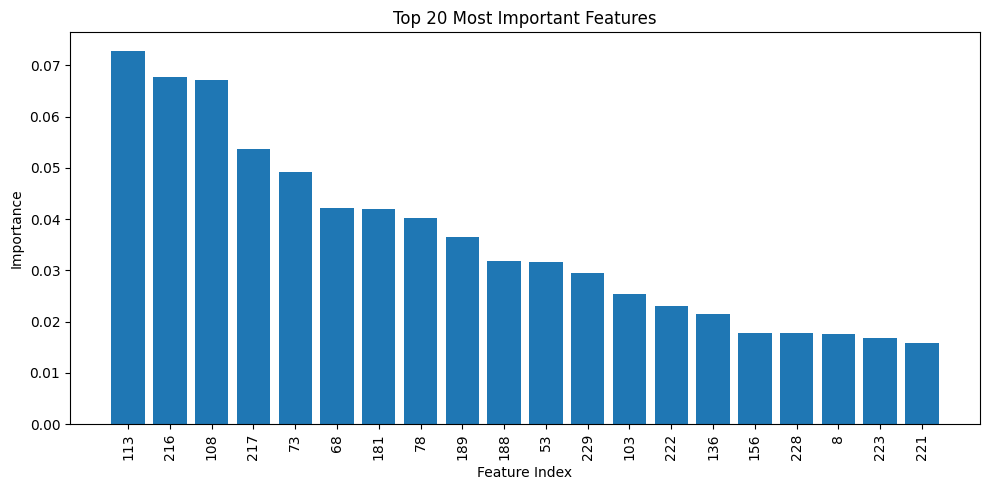

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar(range(len(idx)), importance[idx])
plt.xticks(range(len(idx)), idx, rotation=90)
plt.title("Top 20 Most Important Features")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
import wfdb

ann = wfdb.rdann(
    "/Users/tanishkabajpai/Downloads/chb01_04.edf",
    extension="seizures"
)

print(ann.sample)

[375552 382464]


In [ ]:
raw4 = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_04.edf",
    preload=True,
    verbose=False
)

data4 = raw4.get_data()

print(data4.shape)

/tmp/ipykernel_44647/3010822088.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw4 = mne.io.read_raw_edf(


(23, 921600)


In [ ]:
data4 = bandpass_filter(data4)

data4 = (
    data4 -
    np.mean(data4, axis=1, keepdims=True)
) / (
    np.std(data4, axis=1, keepdims=True) + 1e-8
)

NameError: name 'bandpass_filter' is not defined

In [ ]:
WINDOW_SIZE = 256

windows4 = []

for start in range(
    0,
    data4.shape[1] - WINDOW_SIZE,
    WINDOW_SIZE
):
    windows4.append(
        data4[:, start:start+WINDOW_SIZE]
    )

windows4 = np.array(windows4)

print(windows4.shape)

(3599, 23, 256)


In [ ]:
time_features4 = []

for win in windows4:
    time_features4.append(
        extract_time_features(win)
    )

time_features4 = np.array(time_features4)

print(time_features4.shape)

(3599, 115)


In [ ]:
frequency_features4 = []

for win in windows4:
    frequency_features4.append(
        extract_frequency_features(win)
    )

frequency_features4 = np.array(
    frequency_features4
)

print(frequency_features4.shape)

(3599, 115)


In [ ]:
entropy_features4 = []

for win in windows4:
    entropy_features4.append(
        extract_entropy_features(win)
    )

entropy_features4 = np.array(
    entropy_features4
)

print(entropy_features4.shape)

(3599, 23)


In [ ]:
X4 = np.hstack([
    time_features4,
    frequency_features4,
    entropy_features4
])

print(X4.shape)

(3599, 253)


In [ ]:
y4 = np.zeros(len(windows4))

for i in range(len(windows4)):

    window_start = i
    window_end = i + 1

    if (
        window_end > 1467
        and
        window_start < 1494
    ):
        y4[i] = 1

print("Seizure windows:", int(np.sum(y4)))

Seizure windows: 27


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X4,
    y4,
    test_size=0.2,
    random_state=42,
    stratify=y4
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print(np.bincount(y_train_balanced.astype(int)))

[2857 2857]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf4 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

rf4.fit(
    X_train_balanced,
    y_train_balanced
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=15,
                       n_estimators=300, random_state=42)

In [ ]:
y_prob = rf4.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.50).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sensitivity:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9986111111111111
Sensitivity: 0.8
F1 Score: 0.8888888888888888


In [ ]:
import wfdb

def get_seizure_times(edf_path):

    ann = wfdb.rdann(
        edf_path,
        extension="seizures"
    )

    start_sec = ann.sample[0] / 256
    end_sec = ann.sample[1] / 256

    return start_sec, end_sec

In [ ]:
print(X4.shape)
print(y4.shape)
print(np.sum(y4))

(3599, 253)
(3599,)
27.0


In [ ]:
def create_labels(n_windows, start_sec, end_sec):

    y = np.zeros(n_windows)

    for i in range(n_windows):

        window_start = i
        window_end = i + 1

        if (
            window_end > start_sec
            and
            window_start < end_sec
        ):
            y[i] = 1

    return y

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

def evaluate_model(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    smote = SMOTE(random_state=42)

    X_train_balanced, y_train_balanced = smote.fit_resample(
        X_train,
        y_train
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight="balanced_subsample",
        random_state=42
    )

    rf.fit(
        X_train_balanced,
        y_train_balanced
    )

    y_prob = rf.predict_proba(X_test)[:,1]

    y_pred = (y_prob > 0.50).astype(int)

    return (
        accuracy_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    )

In [ ]:
files = [
    "chb01_15.edf",
    "chb01_16.edf",
    "chb01_18.edf",
    "chb01_21.edf",
    "chb01_26.edf"
]

In [ ]:
ann = wfdb.rdann(
    "/Users/tanishkabajpai/Downloads/chb01_15.edf",
    extension="seizures"
)

print(ann.sample)

[443392 453632]


In [ ]:
y15 = np.zeros(len(windows15))

for i in range(len(windows15)):

    window_start = i
    window_end = i + 1

    if (
        window_end > 1732
        and
        window_start < 1772
    ):
        y15[i] = 1

print("Seizure windows:", int(np.sum(y15)))

NameError: name 'windows15' is not defined

In [ ]:
raw15 = mne.io.read_raw_edf(
    "/Users/tanishkabajpai/Downloads/chb01_15.edf",
    preload=True,
    verbose=False
)

data15 = raw15.get_data()

print(data15.shape)

/tmp/ipykernel_44647/523105671.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw15 = mne.io.read_raw_edf(


(23, 921600)


In [ ]:
data15 = bandpass_filter(data15)

data15 = (
    data15 -
    np.mean(data15, axis=1, keepdims=True)
) / (
    np.std(data15, axis=1, keepdims=True) + 1e-8
)

In [ ]:
WINDOW_SIZE = 256

windows15 = []

for start in range(
    0,
    data15.shape[1] - WINDOW_SIZE,
    WINDOW_SIZE
):
    windows15.append(
        data15[:, start:start+WINDOW_SIZE]
    )

windows15 = np.array(windows15)

print(windows15.shape)

(3599, 23, 256)


In [ ]:
time_features15 = np.array([
    extract_time_features(win)
    for win in windows15
])

frequency_features15 = np.array([
    extract_frequency_features(win)
    for win in windows15
])

entropy_features15 = np.array([
    extract_entropy_features(win)
    for win in windows15
])

In [ ]:
X15 = np.hstack([
    time_features15,
    frequency_features15,
    entropy_features15
])

print(X15.shape)

(3599, 253)


In [ ]:
y15 = np.zeros(len(windows15))

for i in range(len(windows15)):

    if (i + 1) > 1732 and i < 1772:
        y15[i] = 1

print("Seizure windows:", int(np.sum(y15)))

Seizure windows: 40


In [ ]:
print(windows15.shape)
print(X15.shape)
print(np.sum(y15))

(3599, 23, 256)
(3599, 253)
40.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X15,
    y15,
    test_size=0.2,
    random_state=42,
    stratify=y15
)

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

rf15 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

rf15.fit(
    X_train_balanced,
    y_train_balanced
)

y_prob = rf15.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.50).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sensitivity:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9958333333333333
Sensitivity: 0.625
F1 Score: 0.7692307692307693


In [ ]:
baseline4 = np.hstack([
    time_features4,
    frequency_features4
])

print(baseline4.shape)

(3599, 230)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    baseline4,
    y4,
    test_size=0.2,
    random_state=42,
    stratify=y4
)

rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sensitivity:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9986111111111111
Sensitivity: 0.8
F1: 0.8888888888888888


In [ ]:
baseline15 = np.hstack([
    time_features15,
    frequency_features15
])

print(baseline15.shape)

(3599, 230)


In [37]:
print("windows exists:", "windows" in globals())
print("windows4 exists:", "windows4" in globals())
print("y exists:", "y" in globals())
print("y4 exists:", "y4" in globals())

windows exists: True
windows4 exists: False
y exists: False
y4 exists: False


In [38]:
y = np.zeros(len(windows))

for i in range(len(windows)):

    window_start = i * 256
    window_end = (i + 1) * 256

    if (
        window_end > 766976 and
        window_start < 777216
    ):
        y[i] = 1

print("Seizure windows:", int(np.sum(y)))
print(y.shape)

Seizure windows: 40
(3599,)


In [39]:
print(X.shape)
print(y.shape)

(3599, 276)
(3599,)


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Sensitivity:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)

Accuracy: 0.9986111111111111
Sensitivity: 0.875
F1 Score: 0.9333333333333333


In [41]:
importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar(range(20), importance[idx])
plt.xticks(range(20), idx, rotation=90)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance_enhanced.png", dpi=300)
plt.show()

NameError: name 'plt' is not defined

In [42]:
import matplotlib.pyplot as plt
import numpy as np

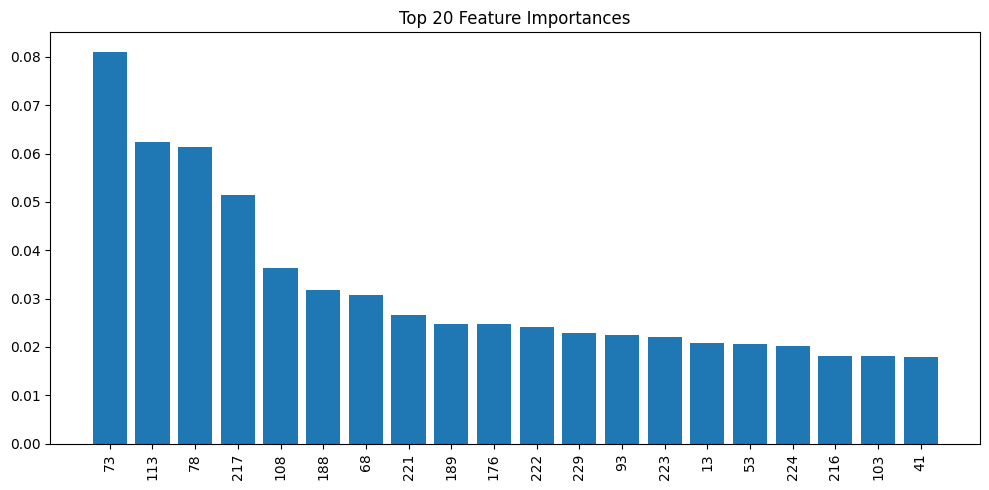

In [43]:
importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar(range(20), importance[idx])
plt.xticks(range(20), idx, rotation=90)
plt.title("Top 20 Feature Importances")
plt.tight_layout()

plt.savefig(
    "feature_importance_enhanced.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
plt.savefig("feature_importance_enhanced.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [46]:
print("rf exists:", "rf" in globals())

rf exists: True


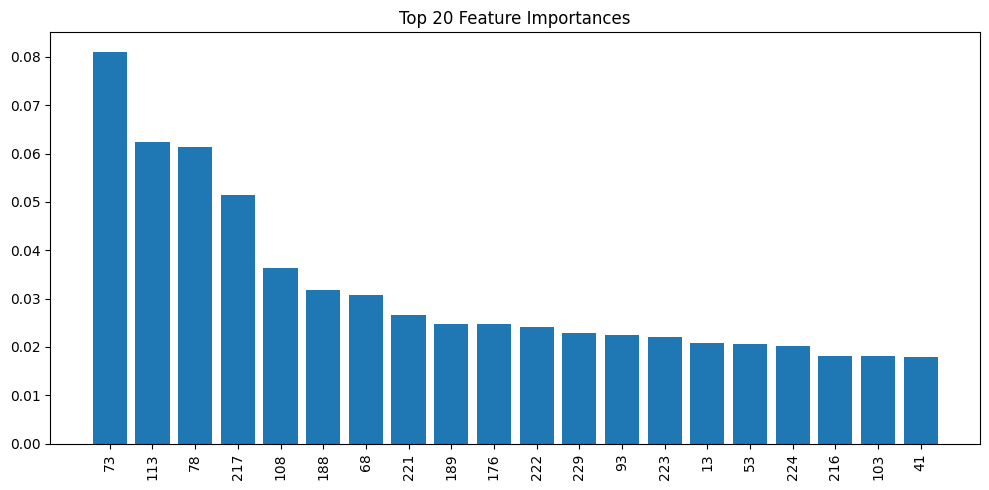

In [47]:
import matplotlib.pyplot as plt
import numpy as np

importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar(range(20), importance[idx])
plt.xticks(range(20), idx, rotation=90)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [45]:
git add .
git commit -m "Added permutation entropy features and improved seizure detection performance"
git push

SyntaxError: invalid syntax (82440895.py, line 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    baseline15,
    y15,
    test_size=0.2,
    random_state=42,
    stratify=y15
)

rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Sensitivity:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9944444444444445
Sensitivity: 0.5
F1: 0.6666666666666666


In [ ]:
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

NameError: name 'plt' is not defined

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar(range(len(idx)), importance[idx])
plt.xticks(range(len(idx)), idx, rotation=90)
plt.title("Top 20 Most Important Features")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'rf' is not defined

In [48]:
print("rf exists:", "rf" in globals())

rf exists: True


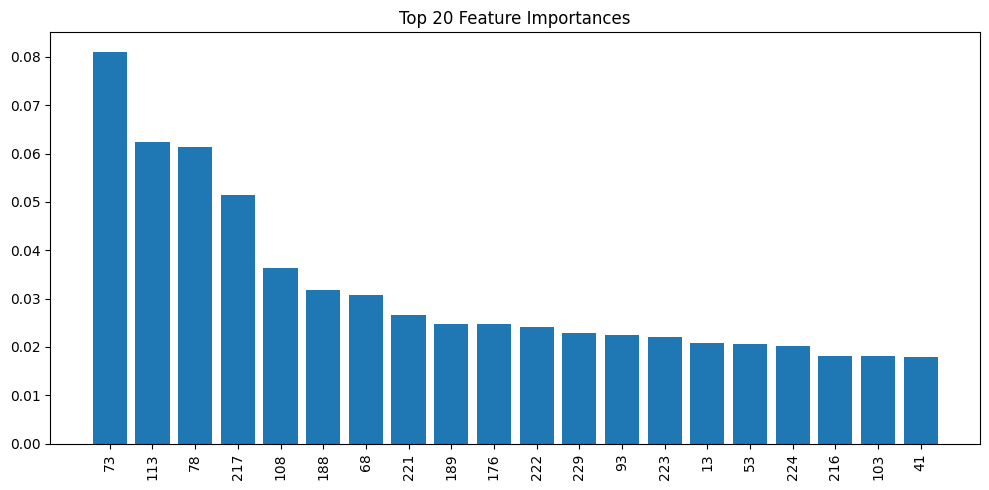

FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/feature_importance_enhanced.png'

In [49]:
import matplotlib.pyplot as plt
import numpy as np

importance = rf.feature_importances_

idx = np.argsort(importance)[::-1][:20]

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(20), importance[idx])

ax.set_xticks(range(20))
ax.set_xticklabels(idx, rotation=90)

ax.set_title("Top 20 Feature Importances")

plt.tight_layout()

plt.show()

fig.savefig(
    "notebooks/feature_importance_enhanced.png",
    dpi=300,
    bbox_inches="tight"
)

In [50]:
import os
print(os.getcwd())

/Users/tanishkabajpai/EEG-Based-Epileptic-Seizure-Detection-Using-Sample-Entropy-and-Random-Forest-Classification/notebooks


In [51]:
fig.savefig(
    "feature_importance_enhanced.png",
    dpi=300,
    bbox_inches="tight"
)